In [5]:
import subprocess
import os
import json
import pandas as pd
import random
import pysam
import numpy as np

In [6]:
!pip install Truvari

In [7]:
!pip install "numpy<1.28" "xgboost>=1.7,<2.0" --force-reinstall

  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached xgboost-1.7.6-py3-none-manylinux2014_x86_64.whl.metadata (1.9 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
Using cached xgboost-1.7.6-py3-none-manylinux2014_x86_64.whl (200.3 MB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy━━━━━━━━━━━━━━━━━━━ 0/3 [numpy]
    Found existing installation: scipy 1.15.3 0/3 [numpy]
    Uninstalling scipy-1.15.3:╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [scipy]
      Successfully uninstalled scipy-1.15.3━━━━━━━━━━━━━━━━━━━ 1/3 [scipy]
  Attempting uninstall: xgboost━━━

In [8]:
import numpy, scipy, xgboost
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("xgboost:", xgboost.__version__)

NumPy: 1.26.4
SciPy: 1.15.3
xgboost: 1.7.6


In [9]:
if not os.path.exists('/home/jupyter/.local/bin/bcftools'):
    !rm -rf htslib bcftools
    !git clone --recurse-submodules https://github.com/samtools/htslib.git
    !git clone https://github.com/samtools/bcftools.git
    !cd bcftools && make
    !cp bcftools/bcftools $HOME/.local/bin/

In [10]:
if not os.path.exists('/home/jupyter/.local/bin/tabix'):
    !wget -O htslib-1.23.tar.bz2 https://github.com/samtools/htslib/releases/download/1.23/htslib-1.23.tar.bz2
    !bunzip2 -c htslib-1.23.tar.bz2 | tar xvf -
    !cd htslib-1.23 && ./configure --prefix=/home/jupyter/.local/bin/ && make && make install
    !cp htslib-1.23/tabix /home/jupyter/.local/bin/

In [11]:
!gsutil ls -lh gs://fc-secure-887f2092-d748-4f3e-aae5-7b114706ebef/for_DRC_techdev/12680.chr6.DEV.g.vcf.bgz

151.26 GiB  2025-11-15T02:09:04Z  gs://fc-secure-887f2092-d748-4f3e-aae5-7b114706ebef/for_DRC_techdev/12680.chr6.DEV.g.vcf.bgz
TOTAL: 1 objects, 162410363711 bytes (151.26 GiB)


In [12]:
!gsutil cat gs://fc-secure-887f2092-d748-4f3e-aae5-7b114706ebef/for_DRC_techdev/12680.chr6.DEV.g.vcf.bgz | zcat | grep -m1 -A1 '^#CHROM' | cut -f1-15

#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	1000234	1000291	1000610	1000612	1000753	1000774
chr6	60937	chr6_60937_T_C	T	C	11	.	AF=0.000158;AQ=11	GT:DP:AD:GQ:PL:RNC	0/0:0:0,0:1:0,0,0:..	0/0:0:0,0:1:0,0,0:..	0/0:0:0,0:1:0,0,0:..	0/0:0:0,0:1:0,0,0:..	0/0:0:0,0:1:0,0,0:..	0/0:0:0,0:1:0,0,0:..

gzip: stdout: Broken pipe


In [13]:
if not os.path.exists('GCA_000001405.15_GRCh38_no_alt_analysis_set.fa'):
    !gsutil cp gs://prod-drc-broad/longreads/references/GRCh38_noalt/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa .
    !gsutil cp gs://prod-drc-broad/longreads/references/GRCh38_noalt/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa.fai .

In [14]:
ref_fa = 'GCA_000001405.15_GRCh38_no_alt_analysis_set.fa'

In [15]:
!gsutil ls -lh gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr2*.g.vcf.bgz

398.88 MiB  2026-03-11T05:43:21Z  gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr20.g.vcf.bgz
262.23 MiB  2026-03-11T06:00:00Z  gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr21.g.vcf.bgz
254.95 MiB  2026-03-11T06:17:10Z  gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr22.g.vcf.bgz
TOTAL: 3 objects, 960558230 bytes (916.06 MiB)


In [16]:
!gsutil cat gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr20.g.vcf.bgz | zcat | grep -A1 -m1 '^#CHROM'
    

#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	HG00097	HG00099	HG00126	HG00128	HG00133	HG00140	HG00146	HG002	HG00232	HG00235	HG00253	HG00272	HG00280	HG00290	HG00320	HG00321	HG00323	HG00329	HG00344	HG00350	HG00408	HG00423	HG00438	HG005	HG00544	HG00558	HG00597	HG00609	HG00621	HG00639	HG00642	HG00658	HG00673	HG00706	HG00733	HG00735	HG00738	HG00741	HG01071	HG01074	HG01081	HG01099	HG01106	HG01109	HG01123	HG01150	HG01167	HG01175	HG01192	HG01243	HG01252	HG01255	HG01258	HG01261	HG01346	HG01358	HG01361	HG01433	HG01496	HG01530	HG01784	HG01786	HG01884	HG01891	HG01928	HG01934	HG01940	HG01943	HG01952	HG01960	HG01969	HG01975	HG01978	HG01981	HG01993	HG02004	HG02015	HG02027	HG02040	HG02055	HG02056	HG02071	HG02074	HG02080	HG02083	HG02109	HG02129	HG02132	HG02135	HG02145	HG02148	HG02155	HG02165	HG02178	HG02257	HG02258	HG02273	HG02280	HG02293	HG02300	HG02391	HG02392	HG02451	HG02486	HG02514	HG02523	HG02559	HG02572	HG02583	HG02602	HG02615	HG02622	HG02630	HG02647	HG02668	HG02698	HG02717	HG02723	HG02735	HG0273

In [17]:
per_chr_joint_vcfs = !gsutil ls gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr*.g.vcf.bgz
    

In [18]:
per_chr_joint_vcfs

['gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr20.g.vcf.bgz',
 'gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr21.g.vcf.bgz',
 'gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr22.g.vcf.bgz']

In [19]:
!wget -O "hprc_release2_sample_metadata.csv" "https://raw.githubusercontent.com/human-pangenomics/hprc_intermediate_assembly/main/data_tables/sample/hprc_release2_sample_metadata.csv"


--2026-03-12 18:58:09--  https://raw.githubusercontent.com/human-pangenomics/hprc_intermediate_assembly/main/data_tables/sample/hprc_release2_sample_metadata.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23578 (23K) [application/octet-stream]
Saving to: ‘hprc_release2_sample_metadata.csv’

hprc_release2_sampl 100%[===================>]  23.03K  --.-KB/s    in 0.002s  

2026-03-12 18:58:09 (9.96 MB/s) - ‘hprc_release2_sample_metadata.csv’ saved [23578/23578]



In [20]:
!gsutil ls gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00097_hap2_hprc_r2_v1.0.1.dipcall.bed

gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00097_hap2_hprc_r2_v1.0.1.dipcall.bed


In [21]:
truth_beds = {
    'HG00097': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00097_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00099': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00099_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00126': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00126_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00128': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00128_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00133': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00133_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00140': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00140_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00146': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00146_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG002': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/hg002v1.1.PanSN.dipcall.bed',
    'HG00232': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00232_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00235': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00235_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00253': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00253_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00272': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00272_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00280': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00280_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00290': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00290_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00320': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00320_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00321': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00321_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00323': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00323_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00329': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00329_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00344': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00344_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00350': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00350_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG00408': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00408_hprc_r2_v1.0.1.dipcall.bed',
    'HG00423': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00423_hprc_r2_v1.0.1.dipcall.bed',
    'HG00438': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00438_hprc_r2_v1.0.1.dipcall.bed',
    'HG005': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG005_hprc_r2_v1.0.1.dipcall.bed',
    'HG00544': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00544_hprc_r2_v1.0.1.dipcall.bed',
    'HG00558': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00558_hprc_r2_v1.0.1.dipcall.bed',
    'HG00597': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00597_hprc_r2_v1.0.1.dipcall.bed',
    'HG00609': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00609_hprc_r2_v1.0.1.dipcall.bed',
    'HG00621': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00621_hprc_r2_v1.0.1.dipcall.bed',
    'HG00639': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00639_hprc_r2_v1.0.1.dipcall.bed',
    'HG00642': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00642_hprc_r2_v1.0.1.dipcall.bed',
    'HG00658': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00658_hprc_r2_v1.0.1.dipcall.bed',
    'HG00673': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00673_hprc_r2_v1.0.1.dipcall.bed',
    'HG00706': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00706_hprc_r2_v1.0.1.dipcall.bed',
    'HG00733': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00733_hprc_r2_v1.0.1.dipcall.bed',
    'HG00735': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00735_hprc_r2_v1.0.1.dipcall.bed',
    'HG00738': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00738_hprc_r2_v1.0.1.dipcall.bed',
    'HG00741': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00741_hprc_r2_v1.0.1.dipcall.bed',
    'HG01071': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01071_hprc_r2_v1.0.1.dipcall.bed',
    'HG01074': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01074_hprc_r2_v1.0.1.dipcall.bed',
    'HG01081': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01081_hprc_r2_v1.0.1.dipcall.bed',
    'HG01099': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01099_hprc_r2_v1.0.1.dipcall.bed',
    'HG01106': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01106_hprc_r2_v1.0.1.dipcall.bed',
    'HG01109': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01109_hprc_r2_v1.0.1.dipcall.bed',
    'HG01123': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01123_hprc_r2_v1.0.1.dipcall.bed',
    'HG01150': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01150_hprc_r2_v1.0.1.dipcall.bed',
    'HG01167': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01167_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG01175': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01175_hprc_r2_v1.0.1.dipcall.bed',
    'HG01192': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01192_hprc_r2_v1.0.1.dipcall.bed',
    'HG01243': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01243_hprc_r2_v1.0.1.dipcall.bed',
    'HG01252': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01252_hprc_r2_v1.0.1.dipcall.bed',
    'HG01255': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01255_hprc_r2_v1.0.1.dipcall.bed',
    'HG01258': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01258_hprc_r2_v1.0.1.dipcall.bed',
    'HG01261': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01261_hprc_r2_v1.0.1.dipcall.bed',
    'HG01346': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01346_hprc_r2_v1.0.1.dipcall.bed',
    'HG01358': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01358_hprc_r2_v1.0.1.dipcall.bed',
    'HG01361': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01361_hprc_r2_v1.0.1.dipcall.bed',
    'HG01433': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01433_hprc_r2_v1.0.1.dipcall.bed',
    'HG01496': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01496_hprc_r2_v1.0.1.dipcall.bed',
    'HG01530': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01530_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG01784': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01784_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG01786': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01786_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG01884': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01884_hprc_r2_v1.0.1.dipcall.bed',
    'HG01891': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01891_hprc_r2_v1.0.1.dipcall.bed',
    'HG01928': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01928_hprc_r2_v1.0.1.dipcall.bed',
    'HG01934': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01934_hprc_r2_v1.0.1.dipcall.bed',
    'HG01940': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01940_hprc_r2_v1.0.1.dipcall.bed',
    'HG01943': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01943_hprc_r2_v1.0.1.dipcall.bed',
    'HG01952': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01952_hprc_r2_v1.0.1.dipcall.bed',
    'HG01960': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01960_hprc_r2_v1.0.1.dipcall.bed',
    'HG01969': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01969_hprc_r2_v1.0.1.dipcall.bed',
    'HG01975': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01975_hprc_r2_v1.0.1.dipcall.bed',
    'HG01978': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01978_hprc_r2_v1.1.0.dipcall.bed',
    'HG01981': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01981_hprc_r2_v1.0.1.dipcall.bed',
    'HG01993': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01993_hprc_r2_v1.0.1.dipcall.bed',
    'HG02004': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02004_hprc_r2_v1.0.1.dipcall.bed',
    'HG02015': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02015_hprc_r2_v1.0.1.dipcall.bed',
    'HG02027': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02027_hprc_r2_v1.0.1.dipcall.bed',
    'HG02040': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02040_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02055': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02055_hprc_r2_v1.0.1.dipcall.bed',
    'HG02056': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02056_hprc_r2_v1.0.1.dipcall.bed',
    'HG02071': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02071_hprc_r2_v1.0.1.dipcall.bed',
    'HG02074': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02074_hprc_r2_v1.0.1.dipcall.bed',
    'HG02080': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02080_hprc_r2_v1.0.1.dipcall.bed',
    'HG02083': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02083_hprc_r2_v1.0.1.dipcall.bed',
    'HG02109': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02109_hprc_r2_v1.0.1.dipcall.bed',
    'HG02129': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02129_hprc_r2_v1.0.1.dipcall.bed',
    'HG02132': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02132_hprc_r2_v1.0.1.dipcall.bed',
    'HG02135': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02135_hprc_r2_v1.0.1.dipcall.bed',
    'HG02145': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02145_hprc_r2_v1.0.1.dipcall.bed',
    'HG02148': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02148_hprc_r2_v1.0.1.dipcall.bed',
    'HG02155': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02155_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02165': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02165_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02178': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02178_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02257': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02257_hprc_r2_v1.1.0.dipcall.bed',
    'HG02258': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02258_hprc_r2_v1.0.1.dipcall.bed',
    'HG02273': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02273_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02280': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02280_hprc_r2_v1.0.1.dipcall.bed',
    'HG02293': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02293_hprc_r2_v1.0.1.dipcall.bed',
    'HG02300': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02300_hprc_r2_v1.0.1.dipcall.bed',
    'HG02391': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02391_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02392': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02392_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02451': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02451_hprc_r2_v1.0.1.dipcall.bed',
    'HG02486': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02486_hprc_r2_v1.0.1.dipcall.bed',
    'HG02514': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02514_hprc_r2_v1.0.1.dipcall.bed',
    'HG02523': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02523_hprc_r2_v1.0.1.dipcall.bed',
    'HG02559': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02559_hprc_r2_v1.0.1.dipcall.bed',
    'HG02572': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02572_hprc_r2_v1.0.1.dipcall.bed',
    'HG02583': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02583_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02602': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02602_hprc_r2_v1.0.1.dipcall.bed',
    'HG02615': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02615_hprc_r2_v1.0.1.dipcall.bed',
    'HG02622': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02622_hprc_r2_v1.0.1.dipcall.bed',
    'HG02630': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02630_hprc_r2_v1.0.1.dipcall.bed',
    'HG02647': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02647_hprc_r2_v1.0.1.dipcall.bed',
    'HG02668': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02668_hprc_r2_v1.0.1.dipcall.bed',
    'HG02698': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02698_hprc_r2_v1.0.1.dipcall.bed',
    'HG02717': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02717_hprc_r2_v1.0.1.dipcall.bed',
    'HG02723': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02723_hprc_r2_v1.0.1.dipcall.bed',
    'HG02735': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02735_hprc_r2_v1.0.1.dipcall.bed',
    'HG02738': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02738_hprc_r2_v1.0.1.dipcall.bed',
    'HG02809': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02809_hprc_r2_v1.0.1.dipcall.bed',
    'HG02818': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02818_hprc_r2_v1.0.1.dipcall.bed',
    'HG02841': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02841_hprc_r2_v1.0.1.dipcall.bed',
    'HG02886': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02886_hprc_r2_v1.0.1.dipcall.bed',
    'HG02922': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02922_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02965': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02965_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02976': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02976_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG02984': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02984_hprc_r2_v1.0.1.dipcall.bed',
    'HG03017': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03017_hprc_r2_v1.0.1.dipcall.bed',
    'HG03041': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03041_hprc_r2_v1.0.1.dipcall.bed',
    'HG03050': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03050_hprc_r2_v1.0.1.dipcall.bed',
    'HG03098': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03098_hprc_r2_v1.0.1.dipcall.bed',
    'HG03130': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03130_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03139': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03139_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03195': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03195_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03209': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03209_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03225': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03225_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03239': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03239_hprc_r2_v1.0.1.dipcall.bed',
    'HG03270': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03270_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03369': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03369_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03453': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03453_hprc_r2_v1.0.1.dipcall.bed',
    'HG03470': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03470_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03471': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03471_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03486': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03486_hprc_r2_v1.0.1.dipcall.bed',
    'HG03492': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03492',
    'HG03516': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03516_hprc_r2_v1.1.0.dipcall.bed',
    'HG03521': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03521_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03540': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03540_hprc_r2_v1.0.1.dipcall.bed',
    'HG03579': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03579_hprc_r2_v1.0.1.dipcall.bed',
    'HG03583': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03583_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03654': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03654_hprc_r2_v1.0.1.dipcall.bed',
    'HG03669': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03669_hprc_r2_v1.0.1.dipcall.bed',
    'HG03688': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03688_hprc_r2_v1.0.1.dipcall.bed',
    'HG03704': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03704_hprc_r2_v1.0.1.dipcall.bed',
    'HG03710': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03710_hprc_r2_v1.0.1.dipcall.bed',
    'HG03742': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03742_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03784': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03784_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03804': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03804_hprc_r2_v1.0.1.dipcall.bed',
    'HG03816': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03816_hprc_r2_v1.0.1.dipcall.bed',
    'HG03831': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03831_hprc_r2_v1.0.1.dipcall.bed',
    'HG03834': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03834_hprc_r2_v1.0.1.dipcall.bed',
    'HG03874': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03874_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'HG03927': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03927_hprc_r2_v1.0.1.dipcall.bed',
    'HG03942': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03942_hprc_r2_v1.0.1.dipcall.bed',
    'HG04115': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04115_hprc_r2_v1.0.1.dipcall.bed',
    'HG04157': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04157_hprc_r2_v1.0.1.dipcall.bed',
    'HG04160': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04160_hprc_r2_v1.0.1.dipcall.bed',
    'HG04184': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04184_hprc_r2_v1.0.1.dipcall.bed',
    'HG04187': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04187_hprc_r2_v1.0.1.dipcall.bed',
    'HG04199': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04199_hprc_r2_v1.0.1.dipcall.bed',
    'HG04204': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04204_hprc_r2_v1.0.1.dipcall.bed',
    'HG04228': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04228_hprc_r2_v1.0.1.dipcall.bed',
    'HG06807': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG06807_v1.0.genbank.dipcall.bed',
    'NA18505': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18505_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18508': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18508_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18522': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18522_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18565': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18565_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18570': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18570_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18608': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18608_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18620': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18620_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18747': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18747_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18879': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18879_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18906': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18906_hprc_r2_v1.0.1.dipcall.bed',
    'NA18940': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18940_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18943': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18943_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18944': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18944_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18945': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18945_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18948': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18948_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18952': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18952_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18959': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18959_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18960': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18960_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18967': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18967_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18970': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18970_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18971': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18971_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18974': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18974_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18976': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18976_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18982': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18982_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA18983': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18983_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19036': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19036_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19043': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19043_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19087': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19087_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19159': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19159_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19185': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19185_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19240': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19240_hprc_r2_v1.0.1.dipcall.bed',
    'NA19338': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19338_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19391': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19391_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19443': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19443_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19468': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19468_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19682': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19682_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19700': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19700_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19776': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19776_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19835': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19835_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA19909': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19909_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20129': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20129_hprc_r2_v1.0.1.dipcall.bed',
    'NA20282': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20282_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20346': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20346_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20503': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20503_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20752': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20752_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20762': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20762_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20799': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20799_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20805': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20805_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20806': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20806_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20809': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20809_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20827': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20827_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20850': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20850_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20870': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20870_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA20905': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20905_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA21093': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21093_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA21102': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21102_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA21106': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21106_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA21110': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21110_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA21144': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21144_hap2_hprc_r2_v1.0.1.dipcall.bed',
    'NA21309': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21309_hprc_r2_v1.0.1.dipcall.bed',
}

In [22]:
truth_vcfs = {
    'HG00097': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00097_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00099': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00099_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00126': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00126_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00128': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00128_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00133': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00133_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00140': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00140_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00146': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00146_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG002': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/hg002v1.1.PanSN.dipcall.vcf.gz',
    'HG00232': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00232_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00235': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00235_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00253': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00253_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00272': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00272_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00280': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00280_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00290': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00290_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00320': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00320_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00321': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00321_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00323': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00323_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00329': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00329_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00344': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00344_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00350': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00350_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00408': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00408_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00423': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00423_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00438': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00438_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG005': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG005_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00544': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00544_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00558': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00558_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00597': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00597_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00609': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00609_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00621': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00621_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00639': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00639_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00642': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00642_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00658': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00658_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00673': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00673_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00706': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00706_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00733': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00733_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00735': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00735_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00738': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00738_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG00741': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00741_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01071': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01071_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01074': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01074_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01081': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01081_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01099': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01099_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01106': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01106_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01109': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01109_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01123': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01123_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01150': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01150_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01167': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01167_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01175': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01175_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01192': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01192_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01243': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01243_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01252': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01252_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01255': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01255_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01258': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01258_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01261': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01261_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01346': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01346_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01358': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01358_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01361': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01361_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01433': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01433_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01496': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01496_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01530': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01530_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01784': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01784_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01786': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01786_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01884': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01884_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01891': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01891_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01928': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01928_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01934': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01934_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01940': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01940_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01943': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01943_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01952': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01952_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01960': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01960_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01969': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01969_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01975': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01975_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01978': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01978_hprc_r2_v1.1.0.dipcall.vcf.gz',
    'HG01981': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01981_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG01993': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG01993_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02004': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02004_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02015': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02015_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02027': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02027_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02040': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02040_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02055': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02055_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02056': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02056_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02071': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02071_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02074': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02074_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02080': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02080_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02083': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02083_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02109': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02109_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02129': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02129_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02132': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02132_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02135': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02135_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02145': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02145_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02148': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02148_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02155': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02155_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02165': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02165_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02178': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02178_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02257': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02257_hprc_r2_v1.1.0.dipcall.vcf.gz',
    'HG02258': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02258_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02273': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02273_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02280': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02280_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02293': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02293_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02300': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02300_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02391': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02391_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02392': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02392_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02451': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02451_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02486': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02486_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02514': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02514_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02523': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02523_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02559': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02559_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02572': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02572_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02583': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02583_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02602': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02602_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02615': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02615_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02622': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02622_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02630': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02630_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02647': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02647_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02668': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02668_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02698': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02698_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02717': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02717_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02723': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02723_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02735': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02735_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02738': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02738_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02809': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02809_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02818': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02818_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02841': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02841_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02886': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02886_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02922': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02922_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02965': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02965_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02976': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02976_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG02984': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG02984_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03017': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03017_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03041': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03041_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03050': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03050_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03098': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03098_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03130': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03130_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03139': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03139_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03195': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03195_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03209': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03209_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03225': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03225_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03239': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03239_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03270': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03270_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03369': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03369_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03453': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03453_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03470': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03470_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03471': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03471_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03486': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03486_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03492': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03492',
    'HG03516': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03516_hprc_r2_v1.1.0.dipcall.vcf.gz',
    'HG03521': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03521_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03540': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03540_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03579': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03579_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03583': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03583_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03654': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03654_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03669': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03669_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03688': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03688_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03704': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03704_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03710': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03710_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03742': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03742_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03784': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03784_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03804': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03804_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03816': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03816_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03831': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03831_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03834': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03834_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03874': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03874_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03927': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03927_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG03942': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG03942_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG04115': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04115_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG04157': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04157_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG04160': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04160_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG04184': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04184_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG04187': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04187_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG04199': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04199_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG04204': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04204_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG04228': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG04228_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'HG06807': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG06807_v1.0.genbank.dipcall.vcf.gz',
    'NA18505': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18505_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18508': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18508_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18522': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18522_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18565': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18565_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18570': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18570_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18608': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18608_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18620': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18620_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18747': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18747_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18879': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18879_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18906': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18906_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18940': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18940_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18943': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18943_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18944': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18944_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18945': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18945_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18948': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18948_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18952': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18952_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18959': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18959_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18960': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18960_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18967': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18967_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18970': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18970_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18971': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18971_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18974': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18974_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18976': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18976_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18982': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18982_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA18983': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA18983_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19036': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19036_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19043': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19043_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19087': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19087_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19159': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19159_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19185': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19185_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19240': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19240_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19338': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19338_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19391': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19391_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19443': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19443_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19468': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19468_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19682': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19682_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19700': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19700_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19776': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19776_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19835': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19835_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA19909': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA19909_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20129': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20129_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20282': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20282_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20346': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20346_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20503': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20503_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20752': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20752_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20762': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20762_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20799': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20799_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20805': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20805_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20806': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20806_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20809': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20809_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20827': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20827_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20850': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20850_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20870': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20870_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA20905': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA20905_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA21093': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21093_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA21102': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21102_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA21106': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21106_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA21110': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21110_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA21144': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21144_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz',
    'NA21309': 'gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21309_hprc_r2_v1.0.1.dipcall.vcf.gz',
}

In [23]:
hprc_df = pd.read_csv("hprc_release2_sample_metadata.csv", encoding="latin1")

In [24]:
pop_to_superpop = {
    # African (AFR)
    "ACB": "AFR",   # African Caribbean in Barbados
    "ASW": "AFR",   # African Ancestry in SW US
    "ESN": "AFR",   # Esan (Nigeria)
    "GWD": "AFR",   # Gambian
    "LWK": "AFR",   # Luhya (Kenya)
    "MSL": "AFR",   # Mende (Sierra Leone)
    "YRI": "AFR",   # Yoruba (Nigeria)
    "MKK": "AFR",   # Maasai (Kenya) – from 1000G pilot
    # (ASL not standard in 1000G; likely African → AFR)
    "ASL": "AFR",

    # European (EUR)
    "FIN": "EUR",   # Finnish
    "GBR": "EUR",   # British
    "IBS": "EUR",   # Iberian
    "TSI": "EUR",   # Toscani

    # East Asian (EAS)
    "CDX": "EAS",   # Dai (China)
    "CHB": "EAS",   # Han (Beijing)
    "CHS": "EAS",   # Han (South)
    "JPT": "EAS",   # Japanese
    "KHV": "EAS",   # Kinh (Vietnam)

    # South Asian (SAS)
    "BEB": "SAS",   # Bengali
    "GIH": "SAS",   # Gujarati (India)
    "ITU": "SAS",   # Indian Telugu
    "PJL": "SAS",   # Punjabi
    "STU": "SAS",   # Sri Lankan Tamil

    # Admixed American (AMR)
    "CLM": "AMR",   # Colombian
    "MXL": "AMR",   # Mexican Ancestry in Los Angeles
    "PEL": "AMR",   # Peruvian
    "PUR": "AMR",   # Puerto Rican
}

hprc_df["superpopulation"] = hprc_df["population_abbreviation"].map(pop_to_superpop)

In [25]:
hprc_df

,sample_id,biosample_id,population_descriptor,population_abbreviation,trio_available,family_id,paternal_id,maternal_id,sex,tissue,collection,alternative_id,notes,superpopulation
0,HG01891,SAMN17861236,African Caribbean in Barbados,ACB,True,BB05,HG01890,HG01889,female,B-Lymphocyte,1000G,NaN,NaN,AFR
1,HG00673,SAMN17861654,"Han Chinese South, China",CHS,True,SH079,HG00671,HG00672,male,B-Lymphocyte,1000G,NaN,NaN,EAS
2,HG00438,SAMN17861652,"Han Chinese South, China",CHS,True,SH012,HG00436,HG00437,female,B-Lymphocyte,1000G,NaN,NaN,EAS
3,HG01071,SAMN17861657,Puerto Rican in Puerto Rico,PUR,True,PR17,HG01069,HG01070,female,B-Lymphocyte,1000G,NaN,NaN,AMR
4,HG00735,SAMN17861655,Puerto Rican in Puerto Rico,PUR,True,PR06,HG01047,HG00734,female,B-Lymphocyte,1000G,NaN,NaN,AMR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,HG005,SAMN03283350,NaN,NaN,True,NaN,HG003,HG004,male,B-Lymphocyte,GIAB,NA26107,NaN,NaN
230,HG06807,SAMN33621959,"African Americans living in St. Louis, Missouri",ASL,True,NaN,HG06804,HG06803,female,NaN,NaN,PAN027,NaN,AFR
231,HG002,SAMN03283347,NaN,NaN,True,NaN,NA24694,NA24695,male,NaN,GIAB,NA24385,NaN,NaN
232,GRCh38,SAMN12121739,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
set(hprc_df['superpopulation'])

{'AFR', 'AMR', 'EAS', 'EUR', 'SAS', nan}

In [27]:
# ── Clean: drop samples without superpopulation or sex info ───────────────────
hprc_clean = hprc_df[
    hprc_df["superpopulation"].notna() &
    hprc_df["sex"].notna()
].copy()

In [28]:
random.seed(42)

SUPERPOPS = ["AFR", "AMR", "EAS", "EUR", "SAS"]
TRAIN_FRAC = 0.75  # 75% train, 25% test

train_samples, test_samples = [], []

for pop in SUPERPOPS:
    pop_df = hprc_clean[hprc_clean["superpopulation"] == pop]

    for sex in ["male", "female"]:
        sex_df    = pop_df[pop_df["sex"] == sex]
        available = sex_df["sample_id"].tolist()
        n         = len(available)

        if n < 2:
            print(f"WARNING: {pop}/{sex} has only {n} samples — skipping")
            continue

        # Proportional split, but guarantee at least 1 in each set
        n_train = max(1, min(n - 1, round(n * TRAIN_FRAC)))
        n_test  = n - n_train

        selected = random.sample(available, k=n)   # shuffle all
        train_samples.extend(selected[:n_train])
        test_samples.extend(selected[n_train:])

        if n < 4:
            print(f"NOTE: {pop}/{sex} only has {n} samples → {n_train} train / {n_test} test")

assert len(set(train_samples) & set(test_samples)) == 0, "Leakage!"

train_df = hprc_clean[hprc_clean["sample_id"].isin(train_samples)].copy()
test_df  = hprc_clean[hprc_clean["sample_id"].isin(test_samples)].copy()

print(f"Train: {len(train_df)} samples")
print(f"Test:  {len(test_df)} samples")
print()
print("Train breakdown (superpop × sex):")
print(train_df.groupby(["superpopulation", "sex"]).size().unstack(fill_value=0))
print()
print("Test breakdown (superpop × sex):")
print(test_df.groupby(["superpopulation", "sex"]).size().unstack(fill_value=0))

Train: 173 samples
Test:  57 samples

Train breakdown (superpop × sex):
sex              female  male
superpopulation              
AFR                  34    19
AMR                  18    15
EAS                  11    26
EUR                  13    10
SAS                  11    16

Test breakdown (superpop × sex):
sex              female  male
superpopulation              
AFR                  11     6
AMR                   6     5
EAS                   4     9
EUR                   4     3
SAS                   4     5


In [29]:
per_chr_joint_vcfs

['gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr20.g.vcf.bgz',
 'gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr21.g.vcf.bgz',
 'gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr22.g.vcf.bgz']

In [30]:
!gsutil cat gs://fc-secure-8f7d6a20-04ce-40d7-8c88-aececeac3e09/scratch/kvg/subset_chr20.g.vcf.bgz | zcat | grep -m1 -A1 '^#CHROM' | cut -f1-15

#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	HG00097	HG00099	HG00126	HG00128	HG00133	HG00140
chr20	60591	chr20_60591_CTCCACTCCAT_C	CTCCACTCCAT	C	31.00	.	AF=0.00215100;AQ=31	GT:RNC:DP:AD:GQ:PL	./.:II:0:0,0:0:0,0,0	0/0:..:0:0,0:0:0,0,0	0/0:..:0:0,0:1:0,0,0	0/0:..:0:0,0:1:0,0,0	0/0:..:0:0,0:1:0,0,0	./.:II:0:0,0:0:0,0,0

gzip: stdout: Broken pipe


In [31]:
import pysam
import pandas as pd
import numpy as np
from collections import defaultdict

def parse_gt(gt_str):
    """Parse GT string to (allele1, allele2, is_phased). Returns None for missing."""
    if gt_str in ('.', './.', '.|.'):
        return None
    phased = '|' in gt_str
    sep = '|' if phased else '/'
    parts = gt_str.split(sep)
    try:
        a1, a2 = int(parts[0]), int(parts[1])
        return a1, a2, phased
    except ValueError:
        return None

def extract_features_from_vcf(vcf_path, ancestry_df=None):
    """
    Extract per-genotype feature matrix from a joint DeepVariant+GLNexus VCF.
    
    Returns a DataFrame with one row per (variant, sample) genotype call,
    excluding reference-only and missing genotypes.
    """
    vcf = pysam.VariantFile(vcf_path)
    samples = list(vcf.header.samples)
    
    # Build sample -> superpopulation lookup if ancestry provided
    if ancestry_df is not None:
        ancestry_map = dict(zip(
            ancestry_df['sample_id'],
            ancestry_df['superpopulation']
        ))
    else:
        ancestry_map = {}

    records = []

    for variant in vcf.fetch():
        chrom = variant.chrom
        pos   = variant.pos       # 1-based in pysam
        ref   = variant.ref
        alts  = variant.alts      # tuple; None if no ALT

        if alts is None:
            continue

        # Skip reference blocks (GLNexus emits <NON_REF> blocks)
        if all(a in ('<NON_REF>', '<*>') for a in alts):
            continue

        # INFO fields
        info_af = variant.info.get('AF', (np.nan,))
        info_af = info_af[0] if isinstance(info_af, tuple) else info_af
        info_aq = variant.info.get('AQ', np.nan)

        # Variant type (before any splitting)
        is_snv = len(ref) == 1 and all(len(a) == 1 for a in alts if a not in ('<NON_REF>', '<*>'))

        for sample in samples:
            s = variant.samples[sample]

            gt_tuple = s.get('GT', None)
            if gt_tuple is None or None in gt_tuple:
                continue   # missing GT

            a1, a2 = gt_tuple
            # Skip hom-ref
            if a1 == 0 and a2 == 0:
                continue

            # Which ALT index is this call? (for split-multi handling)
            alt_indices = {i for i in (a1, a2) if i is not None and i > 0}
            
            # For now, record one row per non-ref allele present
            # (handles multiallelic by iterating alt_indices)
            for alt_idx in alt_indices:
                if alt_idx > len(alts):
                    continue
                alt = alts[alt_idx - 1]
                if alt in ('<NON_REF>', '<*>'):
                    continue

                dp  = s.get('DP', np.nan)
                gq  = s.get('GQ', np.nan)
                ad  = s.get('AD', None)
                pl  = s.get('PL', None)
                rnc = s.get('RNC', None)

                # Allele balance: AD[alt_idx] / sum(AD)
                # pysam can return tuples with None elements for partially missing AD
                if ad is not None:
                    ad_clean = [x if x is not None else 0 for x in ad]
                    total_ad = sum(ad_clean)
                    if total_ad > 0 and alt_idx < len(ad_clean):
                        ab     = ad_clean[alt_idx] / total_ad
                        alt_ad = ad_clean[alt_idx]
                        ref_ad = ad_clean[0]
                    else:
                        ab = alt_ad = ref_ad = np.nan
                else:
                    ab = alt_ad = ref_ad = np.nan

                # PL fields
                pl_ref = pl[0] if pl is not None and len(pl) > 0 else np.nan
                pl_het = pl[1] if pl is not None and len(pl) > 1 else np.nan
                pl_hom = pl[2] if pl is not None and len(pl) > 2 else np.nan

                # GT class
                is_het     = (a1 != a2)
                is_hom_alt = (a1 == a2 and a1 > 0)

                # RNC: bad codes from DeepVariant
                rnc_bad = False
                if rnc is not None:
                    rnc_str = ''.join(str(r) for r in rnc) if isinstance(rnc, tuple) else str(rnc)
                    rnc_bad = any(c in rnc_str for c in ('I', 'U'))

                records.append({
                    'chrom':      chrom,
                    'pos':        pos,
                    'ref':        ref,
                    'alt':        alt,
                    'sample':     sample,
                    'superpop':   ancestry_map.get(sample, np.nan),
                    # Raw FORMAT fields
                    'DP':         dp,
                    'GQ':         gq,
                    'AB':         ab,
                    'alt_AD':     alt_ad,
                    'ref_AD':     ref_ad,
                    'PL_ref':     pl_ref,
                    'PL_het':     pl_het,
                    'PL_hom':     pl_hom,
                    'RNC_bad':    rnc_bad,
                    # Derived
                    'is_snv':     is_snv,
                    'is_het':     is_het,
                    'is_hom_alt': is_hom_alt,
                    # Site-level INFO
                    'site_AF':    info_af,
                    'site_AQ':    info_aq,
                })

    vcf.close()
    return pd.DataFrame(records)

In [32]:
LOCAL_DIR = os.getcwd()

In [33]:
# Download VCFs and their indices
local_vcf_paths = []
for gcs_path in per_chr_joint_vcfs:
    filename = os.path.basename(gcs_path)
    local_path = os.path.join(LOCAL_DIR, filename)
    tbi_path = local_path + '.tbi'
    
    if not os.path.exists(local_path):
        print(f'Downloading {gcs_path}...')
        subprocess.run(['gsutil', 'cp', gcs_path, local_path], check=True)
    else:
        print(f'Already exists, skipping: {local_path}')
    
    if not os.path.exists(tbi_path):
        print(f'Downloading {gcs_path}.tbi...')
        subprocess.run(['gsutil', 'cp', gcs_path + '.tbi', tbi_path], check=True)
    
    local_vcf_paths.append(local_path)

Already exists, skipping: /home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/subset_chr20.g.vcf.bgz
Already exists, skipping: /home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/subset_chr21.g.vcf.bgz
Already exists, skipping: /home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/subset_chr22.g.vcf.bgz


In [ ]:
# Normalize VCFs with bcftools for consistent indel representation (left-align, trim).
# This ensures callset and dipcall truth use the same REF/ALT representation so
# (chrom, pos, ref, alt) matching does not miss equivalent indels.
def _ensure_filter_in_header(header_text, filter_id="MONOALLELIC", description="Monoallelic site"):
    """Add ##FILTER line if filter_id is not already in the header."""
    if f"ID={filter_id}," in header_text or f"ID={filter_id}>" in header_text:
        return header_text
    line = f"##FILTER=<ID={filter_id},Description=\"{description}\">\n"
    # Insert before the #CHROM line (last header line)
    if "#CHROM" in header_text:
        parts = header_text.rsplit("#CHROM", 1)
        return parts[0] + line + "#CHROM" + parts[1]
    return header_text + line


def normalize_vcf(in_path, out_path, ref_fa):
    """Run bcftools norm -f ref -m - and index. Fixes missing FILTER header first if needed."""
    # GLNexus/DeepVariant VCFs may use FILTER=MONOALLELIC not declared in header; bcftools norm then fails.
    header_out = subprocess.run(
        ["bcftools", "view", "-h", in_path], capture_output=True, text=True, check=True
    )
    header_text = header_out.stdout
    fixed_header = _ensure_filter_in_header(header_text)
    to_norm = in_path
    rehead_plain = None
    if fixed_header != header_text:
        rehead_plain = out_path.replace(".norm.g.vcf.gz", ".rehead.vcf")
        # Avoid indexing intermediate reheader output; bcftools norm can read plain VCF.
        subprocess.run(
            ["bcftools", "reheader", "-h", "-", "-o", rehead_plain, in_path],
            input=fixed_header, text=True, check=True,
        )
        to_norm = rehead_plain
    norm_unsorted = out_path.replace(".norm.g.vcf.gz", ".norm.unsorted.g.vcf.gz")
    subprocess.run(
        ["bcftools", "norm", "-f", ref_fa, "-m", "-", "-Oz", "-o", norm_unsorted, to_norm],
        check=True,
    )
    # Left-alignment can move records backward; sort before tabix indexing.
    subprocess.run(["bcftools", "sort", "-Oz", "-o", out_path, norm_unsorted], check=True)
    subprocess.run(["tabix", "-p", "vcf", out_path], check=True)
    if rehead_plain and os.path.exists(rehead_plain):
        try:
            os.unlink(rehead_plain)
        except Exception:
            pass
    if os.path.exists(norm_unsorted):
        try:
            os.unlink(norm_unsorted)
        except Exception:
            pass


local_norm_vcf_paths = []
for vcf_path in local_vcf_paths:
    base = vcf_path.replace(".g.vcf.bgz", "").replace(".vcf.bgz", "").replace(".vcf.gz", "")
    norm_path = base + ".norm.g.vcf.gz"
    if not os.path.exists(norm_path):
        print(f"Normalizing {vcf_path} -> {norm_path}")
        normalize_vcf(vcf_path, norm_path, ref_fa)
    else:
        print(f"Already normalized: {norm_path}")
    local_norm_vcf_paths.append(norm_path)

# Use normalized VCFs for all downstream evaluation (geno_df, truth matching)
local_vcf_paths = local_norm_vcf_paths

In [34]:
train_samples = list(train_df['sample_id'])
test_samples = list(test_df['sample_id'])

In [35]:
from collections import defaultdict

TRAIN_SAMPLES = set(train_samples)
TEST_SAMPLES  = set(test_samples)
LABELED_SAMPLES = TRAIN_SAMPLES | TEST_SAMPLES

def get_info_scalar(variant, key):
    val = variant.info.get(key, (np.nan,))
    return val[0] if isinstance(val, tuple) else float(val)

def stream_vcf(vcf_path, ancestry_df, region=None):
    """
    Single-pass streaming over a VCF.
    Returns:
      site_stats_df  — one row per variant with call rate, per-superpop GT counts for HWE
      geno_df        — one row per non-ref genotype for labeled (train+test) samples only
    """
    ancestry_map = dict(zip(ancestry_df['sample_id'], ancestry_df['superpopulation']))
    
    vcf = pysam.VariantFile(vcf_path)
    
    if region is not None:
        chrom, start, end = region
        fetch_iter = vcf.fetch(chrom, start, end)
    else:
        fetch_iter = vcf.fetch()
    
    all_samples = list(vcf.header.samples)
    
    # Pre-partition sample indices by superpop for fast HWE accumulation
    # We need hom-ref counts too, so we can't skip them for site stats
    sample_superpop = {s: ancestry_map.get(s, None) for s in all_samples}
    
    site_records = []
    geno_records = []

    #for variant in vcf.fetch():
    for variant in fetch_iter:        
        alts = variant.alts
        if alts is None:
            continue
        if all(a in ('<NON_REF>', '<*>') for a in alts):
            continue

        chrom    = variant.chrom
        pos      = variant.pos
        ref      = variant.ref
        #info_af  = variant.info.get('AF', (np.nan,))
        #info_af  = info_af[0] if isinstance(info_af, tuple) else float(info_af)
        #info_aq  = float(variant.info.get('AQ', np.nan))
        info_af = get_info_scalar(variant, 'AF')
        info_aq = get_info_scalar(variant, 'AQ')
        is_snv   = len(ref) == 1 and all(len(a) == 1 for a in alts if a not in ('<NON_REF>', '<*>'))

        # Per-superpop GT counters for HWE: {superpop: [n_hom_ref, n_het, n_hom_alt, n_missing]}
        sp_counts = {sp: [0, 0, 0, 0] for sp in SUPERPOPS}
        n_called  = 0
        n_total   = 0

        for sample in all_samples:
            s        = variant.samples[sample]
            gt_tuple = s.get('GT', None)
            sp       = sample_superpop.get(sample)
            n_total += 1

            # Classify GT for site-level stats (all samples)
            if gt_tuple is None or None in gt_tuple:
                if sp in sp_counts:
                    sp_counts[sp][3] += 1   # missing
                continue

            a1, a2   = gt_tuple
            n_called += 1

            if sp in sp_counts:
                if a1 == 0 and a2 == 0:
                    sp_counts[sp][0] += 1   # hom-ref
                elif a1 != a2:
                    sp_counts[sp][1] += 1   # het
                else:
                    sp_counts[sp][2] += 1   # hom-alt

            # Genotype feature rows: labeled samples, non-ref only
            if sample not in LABELED_SAMPLES:
                continue
            if a1 == 0 and a2 == 0:
                continue

            alt_indices = {i for i in (a1, a2) if i is not None and i > 0}
            for alt_idx in alt_indices:
                if alt_idx > len(alts):
                    continue
                alt = alts[alt_idx - 1]
                if alt in ('<NON_REF>', '<*>'):
                    continue

                dp  = s.get('DP',  np.nan)
                gq  = s.get('GQ',  np.nan)
                ad  = s.get('AD',  None)
                pl  = s.get('PL',  None)
                rnc = s.get('RNC', None)

                if ad is not None:
                    ad_clean  = [x if x is not None else 0 for x in ad]
                    total_ad  = sum(ad_clean)
                    if total_ad > 0 and alt_idx < len(ad_clean):
                        ab     = ad_clean[alt_idx] / total_ad
                        alt_ad = ad_clean[alt_idx]
                        ref_ad = ad_clean[0]
                    else:
                        ab = alt_ad = ref_ad = np.nan
                else:
                    ab = alt_ad = ref_ad = np.nan

                pl_clean = [x if x is not None else np.nan for x in pl] if pl is not None else [np.nan]*3

                rnc_bad = False
                if rnc is not None:
                    rnc_str = ''.join(str(r) for r in rnc) if isinstance(rnc, tuple) else str(rnc)
                    rnc_bad = any(c in rnc_str for c in ('I', 'U'))

                geno_records.append({
                    'chrom':      chrom,
                    'pos':        pos,
                    'ref':        ref,
                    'alt':        alt,
                    'sample':     sample,
                    'split':      'train' if sample in TRAIN_SAMPLES else 'test',
                    'superpop':   sp,
                    'DP':         dp,
                    'GQ':         gq,
                    'AB':         ab,
                    'alt_AD':     alt_ad,
                    'ref_AD':     ref_ad,
                    'PL_ref':     pl_clean[0],
                    'PL_het':     pl_clean[1],
                    'PL_hom':     pl_clean[2],
                    'RNC_bad':    rnc_bad,
                    'is_snv':     is_snv,
                    'is_het':     (a1 != a2),
                    'is_hom_alt': (a1 == a2 and a1 > 0),
                    'site_AF':    info_af,
                    'site_AQ':    info_aq,
                })

        site_records.append({
            'chrom':    chrom,
            'pos':      pos,
            'ref':      ref,
            'alts':     ','.join(alts),
            'is_snv':   is_snv,
            'n_called': n_called,
            'n_total':  n_total,
            'call_rate': n_called / n_total if n_total > 0 else np.nan,
            **{f'n_hom_ref_{sp}': sp_counts[sp][0] for sp in SUPERPOPS},
            **{f'n_het_{sp}':     sp_counts[sp][1] for sp in SUPERPOPS},
            **{f'n_hom_alt_{sp}': sp_counts[sp][2] for sp in SUPERPOPS},
            **{f'n_miss_{sp}':    sp_counts[sp][3] for sp in SUPERPOPS},
        })

    vcf.close()
    return pd.DataFrame(site_records), pd.DataFrame(geno_records)

In [36]:
local_vcf_paths

['/home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/subset_chr20.g.vcf.bgz',
 '/home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/subset_chr21.g.vcf.bgz',
 '/home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/subset_chr22.g.vcf.bgz']

In [ ]:
locus_start = 10_000_000
locus_end = 11_000_000

In [37]:
all_site_dfs = []
all_geno_dfs = []

for vcf_path in local_vcf_paths:
    chrom = (
        os.path.basename(vcf_path)
        .replace(".norm.g.vcf.gz", "")
        .replace(".g.vcf.bgz", "")
        .replace("subset_", "")
    )
    
    print(f'Streaming {vcf_path}...')
    site_df, geno_df = stream_vcf(vcf_path, ancestry_df=hprc_df, region=(chrom, locus_start, locus_end))
    all_site_dfs.append(site_df)
    all_geno_dfs.append(geno_df)
    print(f'  {len(site_df):,} sites, {len(geno_df):,} labeled genotypes')

site_df = pd.concat(all_site_dfs, ignore_index=True)
geno_df = pd.concat(all_geno_dfs, ignore_index=True)

print(f'\nTotal sites:            {len(site_df):,}')
print(f'Total labeled genotypes:  {len(geno_df):,}')
print(geno_df['split'].value_counts())

Streaming /home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/subset_chr20.g.vcf.bgz...


[W::bcf_hdr_check_sanity] PL should be declared as Number=G
[W::vcf_parse_filter] FILTER 'MONOALLELIC' is not defined in the header


  13,089 sites, 406,868 labeled genotypes
Streaming /home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/subset_chr21.g.vcf.bgz...


[W::vcf_parse_filter] FILTER 'MONOALLELIC' is not defined in the header


  21,846 sites, 873,849 labeled genotypes
Streaming /home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/subset_chr22.g.vcf.bgz...


[W::vcf_parse_filter] FILTER 'MONOALLELIC' is not defined in the header


  12,703 sites, 383,836 labeled genotypes

Total sites:            47,638
Total labeled genotypes:  1,664,553
split
train    1250314
test      414239
Name: count, dtype: int64


In [38]:
def classify_variant(ref, alt):
    if len(ref) == 1 and len(alt) == 1:
        return 'SNV'
    elif len(alt) > len(ref):
        return 'insertion'
    else:
        return 'deletion'

geno_df['variant_class'] = geno_df.apply(
    lambda r: classify_variant(r['ref'], r['alt']), axis=1
)

print(geno_df['variant_class'].value_counts())

variant_class
SNV          1350551
deletion      166949
insertion     147053
Name: count, dtype: int64


In [39]:
SUBSAMPLE_PER_STRATUM = 50_000

models = {}
train_sets = {}

for vclass in ['SNV', 'insertion', 'deletion']:
    class_df = geno_df[
        (geno_df['split'] == 'train') & 
        (geno_df['variant_class'] == vclass)
    ].copy()
    
    # Stratify by genotype class within each variant type
    sampled = (
        class_df
        .groupby(['is_het', 'is_hom_alt'], group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), SUBSAMPLE_PER_STRATUM), random_state=42))
        .reset_index(drop=True)
    )
    train_sets[vclass] = sampled
    print(f'{vclass}: {len(sampled):,} training rows')
    print(sampled.groupby(['is_het', 'is_hom_alt']).size())
    print()

/tmp/ipykernel_81343/2330434670.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), SUBSAMPLE_PER_STRATUM), random_state=42))


SNV: 100,000 training rows
is_het  is_hom_alt
False   True          50000
True    False         50000
dtype: int64



/tmp/ipykernel_81343/2330434670.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), SUBSAMPLE_PER_STRATUM), random_state=42))


insertion: 71,990 training rows
is_het  is_hom_alt
False   True          21990
True    False         50000
dtype: int64

deletion: 74,343 training rows
is_het  is_hom_alt
False   True          24343
True    False         50000
dtype: int64



/tmp/ipykernel_81343/2330434670.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), SUBSAMPLE_PER_STRATUM), random_state=42))


In [41]:
# Genotype-level evaluation against dipcall truth + threshold & XGBoost filters

import os
import subprocess
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score

# Regions we evaluated from the joint gVCFs
EVAL_REGIONS = {
    "chr20": (locus_start, locus_end),
    "chr21": (locus_start, locus_end),
    "chr22": (locus_start, locus_end),
}

TRUTH_CACHE_DIR = os.path.join(LOCAL_DIR, "dipcall_truth_vcfs")
os.makedirs(TRUTH_CACHE_DIR, exist_ok=True)


def _safe_unlink(path):
    if path and os.path.exists(path):
        try:
            os.unlink(path)
        except Exception:
            pass


def _is_valid_vcf_bgzf(path):
    """Return True if file exists and pysam can open it without truncation errors."""
    if not os.path.exists(path):
        return False
    try:
        vf = pysam.VariantFile(path)
        vf.close()
        return True
    except Exception:
        return False


def ensure_local_truth_vcfs(samples, truth_vcfs, cache_dir=TRUTH_CACHE_DIR, ref_fa=None):
    """Download dipcall truth VCFs for the requested samples if missing.

    If a remote .tbi is missing, try to create a local tabix index instead
    of failing hard. If ref_fa is provided, normalizes indels with bcftools norm
    so REF/ALT match the callset representation for evaluation.

    Returns a dict: sample_id -> local VCF path (normalized if ref_fa given).
    """
    local_paths = {}
    for sample in samples:
        gcs_path = truth_vcfs.get(sample)
        if gcs_path is None:
            continue
        filename = os.path.basename(gcs_path)
        local_vcf = os.path.join(cache_dir, filename)
        local_tbi = local_vcf + ".tbi"
        if not os.path.exists(local_vcf):
            print(f"Downloading truth VCF for {sample}: {gcs_path} → {local_vcf}")
            subprocess.run(["gsutil", "cp", gcs_path, local_vcf], check=True)
        if not os.path.exists(local_tbi):
            print(f"Attempting to download truth index for {sample}: {gcs_path}.tbi → {local_tbi}")
            try:
                subprocess.run(["gsutil", "cp", gcs_path + ".tbi", local_tbi], check=True)
            except subprocess.CalledProcessError:
                print(f"No remote index for {sample}; creating local tabix index...")
                try:
                    subprocess.run(["tabix", "-p", "vcf", local_vcf], check=True)
                except Exception as e:
                    print(f"WARNING: failed to create tabix index for {local_vcf}: {e}")
        out_path = local_vcf
        if ref_fa and os.path.exists(ref_fa):
            base = local_vcf.replace(".vcf.gz", "").replace(".vcf.bgz", "").replace(".vcf", "")
            norm_path = base + ".norm.vcf.gz"
            norm_tbi = norm_path + ".tbi"

            # Rebuild if a previous interrupted run left a truncated/invalid cache file.
            if os.path.exists(norm_path) and not _is_valid_vcf_bgzf(norm_path):
                print(f"Removing invalid cached normalized truth VCF for {sample}: {norm_path}")
                _safe_unlink(norm_path)
                _safe_unlink(norm_tbi)

            if not os.path.exists(norm_path):
                print(f"Normalizing truth VCF for {sample}: {local_vcf} → {norm_path}")
                # Dipcall can contain ambiguous/non-reference-matching REF alleles (e.g. IUPAC codes).
                # -c x drops those problematic records so normalization can proceed.
                norm_unsorted = norm_path.replace(".norm.vcf.gz", ".norm.unsorted.vcf.gz")
                try:
                    subprocess.run(
                        ["bcftools", "norm", "-c", "x", "-f", ref_fa, "-m", "-", "-Oz", "-o", norm_unsorted, local_vcf],
                        check=True,
                    )
                    subprocess.run(["bcftools", "sort", "-Oz", "-o", norm_path, norm_unsorted], check=True)
                    subprocess.run(["tabix", "-p", "vcf", norm_path], check=True)
                except Exception:
                    _safe_unlink(norm_unsorted)
                    _safe_unlink(norm_path)
                    _safe_unlink(norm_tbi)
                    raise
                _safe_unlink(norm_unsorted)
            out_path = norm_path
        local_paths[sample] = out_path
    return local_paths


def _pick_truth_contig_name(vcf, target_chrom):
    """Map a gVCF chrom name (e.g. 'chr20') to the contig name used in a dipcall VCF.

    Prefers exact match; falls back to stripping or adding 'chr'.
    """
    contigs = set(vcf.header.contigs.keys())
    if target_chrom in contigs:
        return target_chrom
    no_chr = target_chrom.replace("chr", "")
    with_chr = "chr" + target_chrom if not target_chrom.startswith("chr") else target_chrom
    if no_chr in contigs:
        return no_chr
    if with_chr in contigs:
        return with_chr
    # Last resort: use target name (will likely raise at fetch time if truly absent)
    return target_chrom


def build_truth_table(truth_local_vcfs, eval_regions=EVAL_REGIONS):
    """Stream dipcall truth VCFs and build an alt-specific truth table.

    Returns DataFrame with columns:
      sample, chrom, pos, ref, alt, truth_state, truth_gt_raw, variant_class
    where truth_state ∈ {'ref','het','hom_alt','missing'}.
    Chrom names are normalized to gVCF-style (keys of eval_regions).
    """
    import pandas as _pd

    records = []
    for sample, vcf_path in truth_local_vcfs.items():
        vcf = pysam.VariantFile(vcf_path)

        # dipcall VCFs should be single-sample, but don't assume the name
        truth_sample_name = next(iter(vcf.header.samples))

        for target_chrom, (start, end) in eval_regions.items():
            truth_chrom = _pick_truth_contig_name(vcf, target_chrom)
            try:
                fetch_iter = vcf.fetch(truth_chrom, start, end)
            except ValueError:
                # Contig might be absent from this truth VCF
                continue

            for rec in fetch_iter:
                ref = rec.ref
                alts = rec.alts or ()
                gt = rec.samples[truth_sample_name].get("GT", None)

                # Determine a raw GT string for debugging
                if gt is None or None in gt:
                    gt_raw = "./."
                else:
                    a1, a2 = gt
                    gt_raw = f"{a1}/{a2}"

                for alt_idx, alt in enumerate(alts, start=1):
                    if alt in ("<NON_REF>", "<*>"):
                        continue

                    # Alt-specific truth state
                    if gt is None or None in gt:
                        truth_state = "missing"
                    else:
                        a1, a2 = gt
                        has1 = (a1 == alt_idx)
                        has2 = (a2 == alt_idx)
                        if not has1 and not has2:
                            truth_state = "ref"
                        elif a1 == alt_idx and a2 == alt_idx:
                            truth_state = "hom_alt"
                        else:
                            # Any configuration where this ALT is present but not hom-alt
                            truth_state = "het"

                    # Variant class using the same logic as geno_df
                    vclass = classify_variant(ref, alt)

                    records.append({
                        "sample": sample,
                        "chrom": target_chrom,  # normalized to match geno_df
                        "pos": rec.pos,
                        "ref": ref,
                        "alt": alt,
                        "truth_state": truth_state,
                        "truth_gt_raw": gt_raw,
                        "variant_class": vclass,
                    })

        vcf.close()

    return _pd.DataFrame(records)


# Build truth table (only for samples that are in train/test and have truth VCFs)
LABELED_SAMPLES_LIST = sorted(LABELED_SAMPLES)
truth_samples = [s for s in LABELED_SAMPLES_LIST if s in truth_vcfs]
print(f"Using dipcall truth for {len(truth_samples)} labeled samples")

truth_local_vcfs = ensure_local_truth_vcfs(truth_samples, truth_vcfs, ref_fa=ref_fa)
truth_df = build_truth_table(truth_local_vcfs, eval_regions=EVAL_REGIONS)
print(f"Truth table: {len(truth_df):,} rows")


# Attach truth to geno_df and define match / metrics
from math import isnan as _isnan


def attach_truth_to_genotypes(geno_df, truth_df):
    key_cols = ["sample", "chrom", "pos", "ref", "alt"]
    truth_small = truth_df[key_cols + ["truth_state"]].drop_duplicates()

    # Avoid merge suffix collisions when geno_df already carries prior truth annotations.
    geno_base = geno_df.drop(columns=["truth_state", "call_state", "matches_truth"], errors="ignore")
    merged = geno_base.merge(truth_small, how="left", on=key_cols)

    def _call_state(row):
        if row["is_hom_alt"]:
            return "hom_alt"
        if row["is_het"]:
            return "het"
        return "other"

    merged["call_state"] = merged.apply(_call_state, axis=1)
    merged["truth_state"] = merged["truth_state"].fillna("unknown")
    merged["matches_truth"] = (
        merged["truth_state"].isin(["het", "hom_alt"]) &
        (merged["truth_state"] == merged["call_state"])
    )
    return merged


def compute_sensitivity_specificity(geno_with_truth, truth_df, variant_class=None, split="test"):
    """Compute per-call metrics and approximate sensitivity/specificity.

    - Sensitivity is TP / (TP + FN) over truth variants with known genotypes.
    - Specificity is computed over positions where truth explicitly reports 'ref'.
    """
    key_cols = ["sample", "chrom", "pos", "ref", "alt"]

    # Restrict to requested split and variant class
    mask = (geno_with_truth["split"] == split)
    if variant_class is not None:
        mask &= (geno_with_truth["variant_class"] == variant_class)
    gsub = geno_with_truth[mask].copy()

    # Truth subset
    tsub = truth_df.copy()
    if variant_class is not None:
        tsub = tsub[tsub["variant_class"] == variant_class]

    split_samples = TRAIN_SAMPLES if split == "train" else TEST_SAMPLES
    tsub = tsub[tsub["sample"].isin(split_samples)]

    # True positives and false positives among variant calls
    is_truth_var = gsub["truth_state"].isin(["het", "hom_alt"])
    is_truth_ref = (gsub["truth_state"] == "ref")

    TP = int((gsub["matches_truth"] & is_truth_var).sum())
    FP = int((~is_truth_var).sum())  # calls where truth is ref/unknown/missing

    # False negatives: truth variants with no corresponding variant call
    truth_var = tsub[tsub["truth_state"].isin(["het", "hom_alt"])]
    truth_keys = set(zip(truth_var["sample"], truth_var["chrom"], truth_var["pos"], truth_var["ref"], truth_var["alt"]))
    call_keys = set(zip(gsub["sample"], gsub["chrom"], gsub["pos"], gsub["ref"], gsub["alt"]))
    FN = len(truth_keys - call_keys)

    # True negatives / specificity: only where truth explicitly says 'ref'
    truth_ref = tsub[tsub["truth_state"] == "ref"]
    truth_ref_keys = set(zip(truth_ref["sample"], truth_ref["chrom"], truth_ref["pos"], truth_ref["ref"], truth_ref["alt"]))
    FP_ref = len([k for k in truth_ref_keys if k in call_keys])
    TN_ref = len(truth_ref_keys) - FP_ref

    sens = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
    spec = TN_ref / (TN_ref + FP_ref) if (TN_ref + FP_ref) > 0 else float("nan")
    prec = TP / (TP + FP) if (TP + FP) > 0 else float("nan")

    return {
        "variant_class": variant_class or "ALL",
        "split": split,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN_ref": TN_ref,
        "sensitivity": sens,
        "specificity_ref": spec,
        "precision": prec,
        "n_calls": len(gsub),
    }


# Attach truth and compute baseline (unfiltered) metrics

geno_with_truth = attach_truth_to_genotypes(geno_df, truth_df)

metrics_baseline = []
for split in ["train", "test"]:
    metrics_baseline.append(compute_sensitivity_specificity(geno_with_truth, truth_df, variant_class=None, split=split))
    for vclass in ["SNV", "insertion", "deletion"]:
        metrics_baseline.append(compute_sensitivity_specificity(geno_with_truth, truth_df, variant_class=vclass, split=split))

print("Baseline (unfiltered) genotype metrics:")
for m in metrics_baseline:
    print(m)


# Simple threshold filter

def apply_simple_threshold(geno):
    g = geno.copy()
    # Start with basic site/format thresholds
    keep = (
        (g["DP"] >= 5) &
        (g["GQ"] >= 20) &
        (~g["RNC_bad"])
    )
    # Allele balance heuristics
    het_mask = g["is_het"]
    hom_alt_mask = g["is_hom_alt"]

    keep &= (~het_mask) | g["AB"].between(0.25, 0.75)
    keep &= (~hom_alt_mask) | (g["AB"] >= 0.8)

    g["passes_threshold"] = keep
    return g


geno_thr = apply_simple_threshold(geno_with_truth)

metrics_threshold = []
for split in ["train", "test"]:
    sub = geno_thr[geno_thr["passes_threshold"]]
    metrics_threshold.append(compute_sensitivity_specificity(sub, truth_df, variant_class=None, split=split))
    for vclass in ["SNV", "insertion", "deletion"]:
        metrics_threshold.append(compute_sensitivity_specificity(sub, truth_df, variant_class=vclass, split=split))

print("\nSimple-threshold filtered genotype metrics:")
for m in metrics_threshold:
    print(m)


# XGBoost genotype classifier (per variant class)

FEATURE_COLS = [
    "DP", "GQ", "AB", "alt_AD", "ref_AD",
    "PL_ref", "PL_het", "PL_hom",
    "RNC_bad", "site_AF", "site_AQ",
    "is_snv", "is_het", "is_hom_alt",
]


def make_feature_matrix(df):
    X = df[FEATURE_COLS].copy()
    for col in ["RNC_bad", "is_snv", "is_het", "is_hom_alt"]:
        X[col] = X[col].astype(int)
    X = X.fillna(-1)
    return X


geno_labeled = geno_with_truth[geno_with_truth["matches_truth"].notna()].copy()

xgb_models = {}

for vclass in ["SNV", "insertion", "deletion"]:
    train_mask = (geno_labeled["split"] == "train") & (geno_labeled["variant_class"] == vclass)
    train_df = geno_labeled[train_mask].copy()

    if train_df.empty:
        print(f"No training data for {vclass}, skipping XGBoost")
        continue

    # Optional subsampling per genotype class to balance
    def _subsample(g):
        n = len(g)
        if n <= SUBSAMPLE_PER_STRATUM:
            return g
        return g.sample(n=SUBSAMPLE_PER_STRATUM, random_state=42)

    train_df = (
        train_df
        .groupby(["is_het", "is_hom_alt", "matches_truth"], group_keys=False)
        .apply(_subsample)
        .reset_index(drop=True)
    )

    X_train = make_feature_matrix(train_df)
    y_train = train_df["matches_truth"].astype(int)

    model = xgb.XGBClassifier(
        max_depth=4,
        n_estimators=200,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        n_jobs=4,
        eval_metric="logloss",
    )
    model.fit(X_train, y_train)
    xgb_models[vclass] = model

    # Evaluate on test set for this variant class
    test_mask = (geno_labeled["split"] == "test") & (geno_labeled["variant_class"] == vclass)
    test_df = geno_labeled[test_mask].copy()
    if not test_df.empty:
        X_test = make_feature_matrix(test_df)
        y_test = test_df["matches_truth"].astype(int)
        y_score = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_score)
        ap = average_precision_score(y_test, y_score)
        print(f"{vclass} XGBoost: test ROC-AUC={auc:.3f}, PR-AUC={ap:.3f} (n={len(test_df):,})")
    else:
        print(f"{vclass} XGBoost: no test data")

# Apply XGBoost model scores to all genotypes

geno_xgb = geno_with_truth.copy()
geno_xgb["xgb_score"] = np.nan

for vclass, model in xgb_models.items():
    mask = (geno_xgb["variant_class"] == vclass)
    if not mask.any():
        continue
    X_all = make_feature_matrix(geno_xgb[mask])
    geno_xgb.loc[mask, "xgb_score"] = model.predict_proba(X_all)[:, 1]

# Find per-class XGBoost threshold that beats unfiltered precision and recall (test set)
def _pr_from_metrics(metrics_list, variant_class, split):
    for m in metrics_list:
        if m["variant_class"] == variant_class and m["split"] == split:
            return m["precision"], m["sensitivity"]
    return float("nan"), float("nan")

threshold_grid = np.linspace(0.05, 0.95, 19)
THRESH_XGB = {}
for vclass in ["SNV", "insertion", "deletion"]:
    p_base, r_base = _pr_from_metrics(metrics_baseline, vclass, "test")
    best_t = 0.5
    for t in threshold_grid:
        geno_xgb["passes_xgb"] = geno_xgb.apply(
            lambda row, tc=vclass, th=t: row["xgb_score"] >= (th if row["variant_class"] == tc else THRESH_XGB.get(row["variant_class"], 0.5)),
            axis=1
        )
        sub = geno_xgb[geno_xgb["passes_xgb"]]
        m = compute_sensitivity_specificity(sub, truth_df, variant_class=vclass, split="test")
        p, r = m["precision"], m["sensitivity"]
        if not (np.isnan(p) or np.isnan(r)) and p >= p_base and r >= r_base:
            best_t = t
            break
    THRESH_XGB[vclass] = best_t

geno_xgb["passes_xgb"] = geno_xgb.apply(
    lambda row: row["xgb_score"] >= THRESH_XGB[row["variant_class"]],
    axis=1
)

metrics_xgb = []
for split in ["train", "test"]:
    sub = geno_xgb[geno_xgb["passes_xgb"]]
    metrics_xgb.append(compute_sensitivity_specificity(sub, truth_df, variant_class=None, split=split))
    for vclass in ["SNV", "insertion", "deletion"]:
        metrics_xgb.append(compute_sensitivity_specificity(sub, truth_df, variant_class=vclass, split=split))

print("XGBoost thresholds (beat unfiltered P/R on test):", THRESH_XGB)
print("\nXGBoost-filtered genotype metrics:")
for m in metrics_xgb:
    print(m)

# Verify: filtering only removes calls, so recall (sensitivity) cannot exceed unfiltered
def _get_sens(metrics_list, vc, spl):
    for m in metrics_list:
        if m.get("variant_class") == vc and m.get("split") == spl:
            return m["sensitivity"]
    return float("nan")
violations = []
for split in ["train", "test"]:
    for vc in [None, "SNV", "insertion", "deletion"]:
        r_base = _get_sens(metrics_baseline, vc or "ALL", split)
        r_thr  = _get_sens(metrics_threshold, vc or "ALL", split)
        r_xgb  = _get_sens(metrics_xgb, vc or "ALL", split)
        if not (np.isnan(r_base) or np.isnan(r_thr)) and r_thr > r_base:
            violations.append(("threshold", vc or "ALL", split, r_base, r_thr))
        if not (np.isnan(r_base) or np.isnan(r_xgb)) and r_xgb > r_base:
            violations.append(("xgb", vc or "ALL", split, r_base, r_xgb))
if violations:
    print("\nWARNING: recall > unfiltered (should not happen):", violations)
else:
    print("\nVerify: recall (sensitivity) never exceeds unfiltered when filtering: OK")

# Update geno_df so subsequent cells (if any) see the annotated, XGBoost-scored DataFrame
geno_df = geno_xgb


Using dipcall truth for 230 labeled samples
Attempting to download truth index for HG00097: gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00097_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz.tbi → /home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/dipcall_truth_vcfs/HG00097_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz.tbi


CommandException: No URLs matched: gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00097_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz.tbi


No remote index for HG00097; creating local tabix index...


Copying gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00099_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz...
- [1 files][ 34.1 MiB/ 34.1 MiB]                                                
Operation completed over 1 objects/34.1 MiB.                                     


Attempting to download truth index for HG00099: gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/HG00099_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz.tbi → /home/jupyter/AoU_DRC_LongReads_PhaseTwo_Storage/edit/dipcall_truth_vcfs/HG00099_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz.tbi


...

SNV XGBoost: test ROC-AUC=0.951, PR-AUC=0.926 (n=336,336)


/tmp/ipykernel_81343/3847058586.py:330: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_subsample)


insertion XGBoost: test ROC-AUC=0.947, PR-AUC=0.870 (n=36,481)


/tmp/ipykernel_81343/3847058586.py:330: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_subsample)


deletion XGBoost: test ROC-AUC=0.937, PR-AUC=0.763 (n=41,422)

XGBoost-filtered genotype metrics (threshold 0.5):
{'variant_class': 'ALL', 'split': 'train', 'TP': 312358, 'FP': 41050, 'FN': 198737, 'TN_ref': 0, 'sensitivity': 0.6111544820434557, 'specificity_ref': nan, 'precision': 0.883845300615719, 'n_calls': 353926}
{'variant_class': 'SNV', 'split': 'train', 'TP': 288992, 'FP': 36513, 'FN': 127364, 'TN_ref': 0, 'sensitivity': 0.6940983197071736, 'specificity_ref': nan, 'precision': 0.8878266078862076, 'n_calls': 325893}
{'variant_class': 'insertion', 'split': 'train', 'TP': 13915, 'FP': 1727, 'FN': 34666, 'TN_ref': 0, 'sensitivity': 0.2864288507852864, 'specificity_ref': nan, 'precision': 0.8895921237693389, 'n_calls': 15731}
{'variant_class': 'deletion', 'split': 'train', 'TP': 9451, 'FP': 2810, 'FN': 36707, 'TN_ref': 0, 'sensitivity': 0.20475323887516791, 'specificity_ref': nan, 'precision': 0.7708180409428268, 'n_calls': 12302}
{'variant_class': 'ALL', 'split': 'test', 'TP': 1048

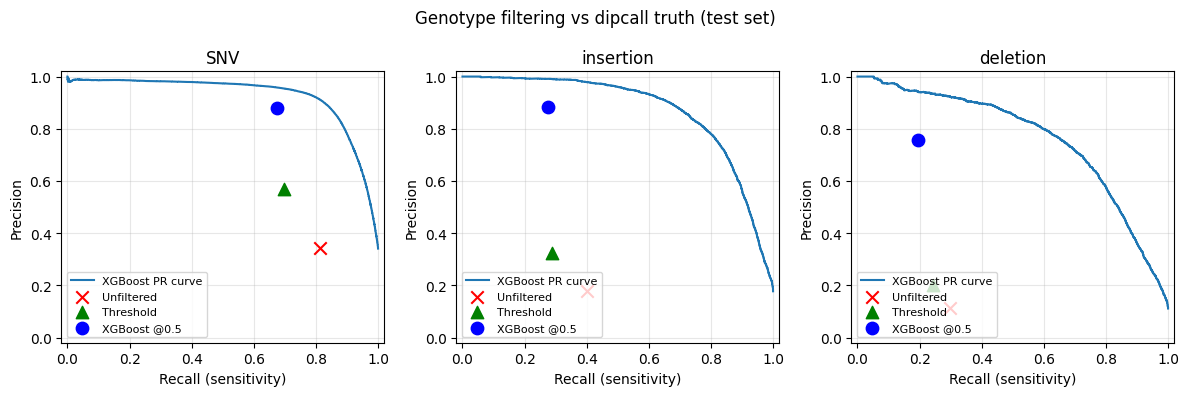

In [43]:
# PR plot: unfiltered, threshold-filtered, and XGBoost (test set)
# Use geno_df for XGBoost curve (it has xgb_score); metrics_* for the three operating points.

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve


def _pr_from_metrics(metrics_list, variant_class, split):
    for m in metrics_list:
        if m["variant_class"] == variant_class and m["split"] == split:
            return m["precision"], m["sensitivity"]
    return float("nan"), float("nan")


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
split = "test"

for ax, variant_class in zip(axes, ["SNV", "insertion", "deletion"]):
    p_base, r_base = _pr_from_metrics(metrics_baseline,  variant_class, split)
    p_thr,  r_thr  = _pr_from_metrics(metrics_threshold, variant_class, split)
    p_xgb,  r_xgb  = _pr_from_metrics(metrics_xgb,       variant_class, split)

    # Full PR curve for XGBoost: use geno_df (has xgb_score)
    mask = (geno_df["split"] == split) & (geno_df["variant_class"] == variant_class)
    test_df = geno_df.loc[mask, ["matches_truth", "xgb_score"]].dropna()
    if len(test_df) > 0:
        y_true = test_df["matches_truth"].astype(int).to_numpy()
        y_score = test_df["xgb_score"].to_numpy()
        prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_score)
        ax.plot(rec_curve, prec_curve, color="C0", label="XGBoost PR curve")

    ax.scatter(r_base, p_base, color="red",   marker="x",  s=80, label="Unfiltered", zorder=5)
    ax.scatter(r_thr,  p_thr,  color="green", marker="^",  s=80, label="Threshold",  zorder=5)
    th = THRESH_XGB.get(variant_class, 0.5)
    ax.scatter(r_xgb,  p_xgb,  color="blue",  marker="o",  s=80, label=f"XGBoost @{th:.2f}", zorder=5)
    ax.set_xlabel("Recall (sensitivity)")
    ax.set_ylabel("Precision")
    ax.set_title(variant_class)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower left", fontsize=8)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

plt.suptitle("Genotype filtering vs dipcall truth (test set)", fontsize=12)
plt.tight_layout()
plt.show()

In [44]:
!gsutil ls gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21144_hap2_hprc_r2_v1.0.1.dipcall.*

gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21144_hap2_hprc_r2_v1.0.1.dipcall.bed
gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21144_hap2_hprc_r2_v1.0.1.dipcall.tar.gz
gs://fc-7f861a33-ddb4-4b2f-8d10-5679c9df6108/dipcall/NA21144_hap2_hprc_r2_v1.0.1.dipcall.vcf.gz


Using confident BEDs for 230 labeled samples
Truth (confident regions only): 481,418 rows
Genotypes in confident regions: 448,514

Baseline (confident regions only):
{'variant_class': 'ALL', 'split': 'train', 'TP': 268347, 'FP': 65126, 'FN': 88941, 'TN_ref': 0, 'sensitivity': 0.7510663666286022, 'specificity_ref': nan, 'precision': 0.8047038290956089, 'n_calls': 336980}
{'variant_class': 'SNV', 'split': 'train', 'TP': 243367, 'FP': 14771, 'FN': 38009, 'TN_ref': 0, 'sensitivity': 0.8649174058910497, 'specificity_ref': nan, 'precision': 0.9427786687740666, 'n_calls': 260978}
{'variant_class': 'insertion', 'split': 'train', 'TP': 13707, 'FP': 21154, 'FN': 24703, 'TN_ref': 0, 'sensitivity': 0.35686019265816193, 'specificity_ref': nan, 'precision': 0.39319009781704484, 'n_calls': 35307}
{'variant_class': 'deletion', 'split': 'train', 'TP': 11273, 'FP': 29201, 'FN': 26229, 'TN_ref': 0, 'sensitivity': 0.30059730147725455, 'specificity_ref': nan, 'precision': 0.27852448485447445, 'n_calls': 40

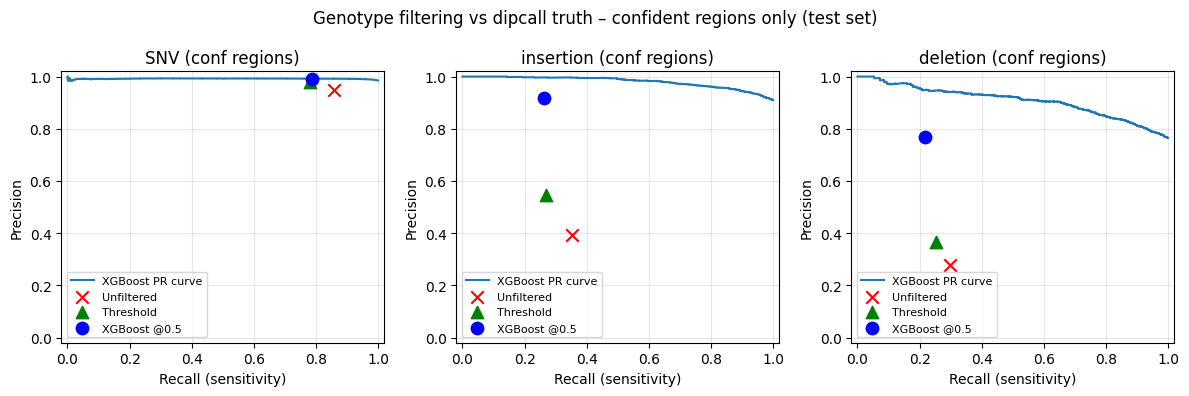

In [47]:
# Restrict evaluation to dipcall-confident regions (per-sample BEDs)

import pandas as pd
import numpy as np
from intervaltree import IntervalTree
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

CONF_BED_CACHE_DIR = os.path.join(LOCAL_DIR, "dipcall_truth_beds")
os.makedirs(CONF_BED_CACHE_DIR, exist_ok=True)

def ensure_local_truth_beds(samples, truth_beds, cache_dir=CONF_BED_CACHE_DIR):
    """Download dipcall BEDs for the requested samples if missing."""
    local_paths = {}
    for sample in samples:
        gcs_path = truth_beds.get(sample)
        if gcs_path is None:
            continue
        filename = os.path.basename(gcs_path)
        local_bed = os.path.join(cache_dir, filename)
        if not os.path.exists(local_bed):
            print(f"Downloading truth BED for {sample}: {gcs_path} → {local_bed}")
            subprocess.run(["gsutil", "cp", gcs_path, local_bed], check=True)
        local_paths[sample] = local_bed
    return local_paths

def _normalize_chrom_to_gvcf(chrom):
    """Map BED/VCF contig names to the gVCF-style names (chr20/21/22)."""
    if chrom.startswith("chr"):
        g = chrom
    else:
        g = "chr" + chrom
    return g if g in EVAL_REGIONS else None

def build_conf_interval_trees(bed_paths, eval_regions=EVAL_REGIONS):
    """Build IntervalTree of confident regions per (sample, chrom)."""
    trees = {}
    for sample, bed_path in bed_paths.items():
        # BED: 0-based start, 1-based end (half-open)
        bed_df = pd.read_csv(
            bed_path,
            sep="\t",
            header=None,
            usecols=[0, 1, 2],
            names=["chrom", "start", "end"],
        )
        for chrom, sub in bed_df.groupby("chrom"):
            gchrom = _normalize_chrom_to_gvcf(chrom)
            if gchrom is None:
                continue
            if gchrom not in eval_regions:
                continue
            tree = IntervalTree()
            for _, row in sub.iterrows():
                tree[row.start : row.end] = True
            trees[(sample, gchrom)] = tree
    return trees

def mark_confident_rows(df, trees):
    """Add 'in_conf' flag to rows of (sample, chrom, pos) using interval trees."""
    df = df.copy()
    df["in_conf"] = False
    # VCF positions are 1-based; BED is 0-based half-open.
    for (sample, chrom), idx in df.groupby(["sample", "chrom"]).groups.items():
        tree = trees.get((sample, chrom))
        if tree is None:
            continue
        pos0 = df.loc[idx, "pos"].to_numpy() - 1
        mask_local = np.fromiter(
            (bool(tree.overlaps(p, p + 1)) for p in pos0),
            dtype=bool,
            count=len(pos0),
        )
        df.loc[idx, "in_conf"] = mask_local
    return df

# --- Build confident-region-aware truth and genotypes ---

LABELED_SAMPLES_LIST = sorted(LABELED_SAMPLES)
truth_samples = [s for s in LABELED_SAMPLES_LIST if s in truth_vcfs and s in truth_beds]
print(f"Using confident BEDs for {len(truth_samples)} labeled samples")

truth_bed_paths = ensure_local_truth_beds(truth_samples, truth_beds)
conf_trees = build_conf_interval_trees(truth_bed_paths, eval_regions=EVAL_REGIONS)

# 1) Restrict truth to confident regions
truth_df_conf = mark_confident_rows(truth_df, conf_trees)
truth_df_conf = truth_df_conf[truth_df_conf["in_conf"]].drop(columns=["in_conf"]).reset_index(drop=True)
print(f"Truth (confident regions only): {len(truth_df_conf):,} rows")

# 2) Attach truth to geno_df again, then restrict to confident regions
# geno_df already has truth_state/call_state/matches_truth; drop so merge doesn't create _x/_y
geno_for_conf = geno_df.drop(columns=["truth_state", "call_state", "matches_truth"], errors="ignore")
geno_with_truth_conf = attach_truth_to_genotypes(geno_for_conf, truth_df_conf)

geno_with_truth_conf = mark_confident_rows(geno_with_truth_conf, conf_trees)
geno_with_truth_conf = geno_with_truth_conf[geno_with_truth_conf["in_conf"]].reset_index(drop=True)

# After: geno_with_truth_conf = geno_with_truth_conf[geno_with_truth_conf["in_conf"]].reset_index(drop=True)
# Add threshold flag so we don't rely on geno_df having it
geno_with_truth_conf = apply_simple_threshold(geno_with_truth_conf)

# Add XGBoost scores from full geno_df so we can filter and plot in confident regions
if "xgb_score" in geno_df.columns and "passes_xgb" in geno_df.columns:
    merge_keys = ["chrom", "pos", "ref", "alt", "sample"]
    scores = geno_df[merge_keys + ["xgb_score", "passes_xgb"]].drop_duplicates(merge_keys)
    geno_with_truth_conf = geno_with_truth_conf.merge(scores, on=merge_keys, how="left")
else:
    geno_with_truth_conf["xgb_score"] = np.nan
    geno_with_truth_conf["passes_xgb"] = False

# Then threshold-filtered subset:
geno_thr_conf = geno_with_truth_conf[geno_with_truth_conf["passes_threshold"]].copy()

print(f"Genotypes in confident regions: {len(geno_with_truth_conf):,}")

# --- Recompute metrics in confident regions ---

metrics_baseline_conf = []
for split in ["train", "test"]:
    metrics_baseline_conf.append(
        compute_sensitivity_specificity(
            geno_with_truth_conf, truth_df_conf, variant_class=None, split=split
        )
    )
    for vclass in ["SNV", "insertion", "deletion"]:
        metrics_baseline_conf.append(
            compute_sensitivity_specificity(
                geno_with_truth_conf, truth_df_conf, variant_class=vclass, split=split
            )
        )

# Threshold: reuse passes_threshold on geno_with_truth_conf
geno_thr_conf = geno_with_truth_conf[geno_with_truth_conf["passes_threshold"]].copy()

metrics_threshold_conf = []
for split in ["train", "test"]:
    metrics_threshold_conf.append(
        compute_sensitivity_specificity(
            geno_thr_conf, truth_df_conf, variant_class=None, split=split
        )
    )
    for vclass in ["SNV", "insertion", "deletion"]:
        metrics_threshold_conf.append(
            compute_sensitivity_specificity(
                geno_thr_conf, truth_df_conf, variant_class=vclass, split=split
            )
        )
        
# XGBoost: reuse xgb_score from geno_df; find per-class threshold that beats unfiltered (confident regions, test)
geno_xgb_conf = geno_with_truth_conf.copy()
for col in ["xgb_score", "passes_xgb"]:
    if col in geno_df.columns:
        geno_xgb_conf[col] = geno_df.set_index(["chrom", "pos", "ref", "alt", "sample"])[
            col
        ].reindex(
            geno_xgb_conf.set_index(["chrom", "pos", "ref", "alt", "sample"]).index
        ).values
if "passes_xgb" not in geno_xgb_conf.columns:
    geno_xgb_conf["passes_xgb"] = False

def _pr_from_metrics_conf(metrics_list, variant_class, split):
    for m in metrics_list:
        if m["variant_class"] == variant_class and m["split"] == split:
            return m["precision"], m["sensitivity"]
    return float("nan"), float("nan")

threshold_grid_conf = np.linspace(0.05, 0.95, 19)
THRESH_XGB_CONF = {}
for vclass in ["SNV", "insertion", "deletion"]:
    p_base, r_base = _pr_from_metrics_conf(metrics_baseline_conf, vclass, "test")
    best_t = 0.5
    for t in threshold_grid_conf:
        geno_xgb_conf["passes_xgb"] = geno_xgb_conf.apply(
            lambda row, tc=vclass, th=t: row["xgb_score"] >= (th if row["variant_class"] == tc else THRESH_XGB_CONF.get(row["variant_class"], 0.5))
            if pd.notna(row["xgb_score"]) else False,
            axis=1
        )
        sub = geno_xgb_conf[geno_xgb_conf["passes_xgb"]]
        m = compute_sensitivity_specificity(sub, truth_df_conf, variant_class=vclass, split="test")
        p, r = m["precision"], m["sensitivity"]
        if not (np.isnan(p) or np.isnan(r)) and p >= p_base and r >= r_base:
            best_t = t
            break
    THRESH_XGB_CONF[vclass] = best_t

geno_xgb_conf["passes_xgb"] = geno_xgb_conf.apply(
    lambda row: row["xgb_score"] >= THRESH_XGB_CONF[row["variant_class"]]
    if pd.notna(row["xgb_score"]) else False,
    axis=1
)
geno_xgb_conf = geno_xgb_conf[geno_xgb_conf["passes_xgb"]].copy()

metrics_xgb_conf = []
for split in ["train", "test"]:
    metrics_xgb_conf.append(
        compute_sensitivity_specificity(
            geno_xgb_conf, truth_df_conf, variant_class=None, split=split
        )
    )
    for vclass in ["SNV", "insertion", "deletion"]:
        metrics_xgb_conf.append(
            compute_sensitivity_specificity(
                geno_xgb_conf, truth_df_conf, variant_class=vclass, split=split
            )
        )

print("\nBaseline (confident regions only):")
for m in metrics_baseline_conf:
    print(m)

print("\nThreshold (confident regions only):")
for m in metrics_threshold_conf:
    print(m)

print("XGBoost thresholds (confident regions, beat unfiltered P/R on test):", THRESH_XGB_CONF)
print("\nXGBoost (confident regions only):")
for m in metrics_xgb_conf:
    print(m)

# --- Optional: PR plots in confident regions (test set) ---

def _pr_from_metrics(metrics_list, variant_class, split):
    for m in metrics_list:
        if m["variant_class"] == variant_class and m["split"] == split:
            return m["precision"], m["sensitivity"]
    return float("nan"), float("nan")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
split = "test"

for ax, variant_class in zip(axes, ["SNV", "insertion", "deletion"]):
    p_base, r_base = _pr_from_metrics(metrics_baseline_conf,  variant_class, split)
    p_thr,  r_thr  = _pr_from_metrics(metrics_threshold_conf, variant_class, split)
    p_xgb,  r_xgb  = _pr_from_metrics(metrics_xgb_conf,       variant_class, split)

    # Full PR curve for XGBoost, confident regions only (use full geno for curve)
    geno_conf_plot = geno_with_truth_conf
    mask = (
        (geno_conf_plot["split"] == split) &
        (geno_conf_plot["variant_class"] == variant_class) &
        geno_conf_plot["xgb_score"].notna()
    )
    curve_df = geno_conf_plot.loc[mask, ["matches_truth", "xgb_score"]]
    if len(curve_df) > 0:
        y_true = curve_df["matches_truth"].astype(int).to_numpy()
        y_score = curve_df["xgb_score"].to_numpy()
        prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_score)
        ax.plot(rec_curve, prec_curve, color="C0", label="XGBoost PR curve")

    ax.scatter(r_base, p_base, color="red",   marker="x",  s=80, label="Unfiltered", zorder=5)
    ax.scatter(r_thr,  p_thr,  color="green", marker="^",  s=80, label="Threshold",  zorder=5)
    th_conf = THRESH_XGB_CONF.get(variant_class, 0.5)
    ax.scatter(r_xgb,  p_xgb,  color="blue",  marker="o",  s=80, label=f"XGBoost @{th_conf:.2f}", zorder=5)
    ax.set_xlabel("Recall (sensitivity)")
    ax.set_ylabel("Precision")
    ax.set_title(f"{variant_class} (conf regions)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower left", fontsize=8)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

plt.suptitle("Genotype filtering vs dipcall truth – confident regions only (test set)", fontsize=12)
plt.tight_layout()
plt.show()